# 12 — Negative sampling: can data do what architecture did?

Every model in this project has trained against negatives drawn uniformly at random from compound × disease pairs that are not `treats` edges. Two separate findings say that is the weakest part of the setup.

**nb11 Part II** — those negatives are contaminated. About 12 % of `y = 0` pairs have registered clinical trials, rising to 28 % in the top-scoring decile. Roughly one in eight negatives is a positive the model is being punished for finding.

**nb11 Part III / nb09** — the negatives are also uninformative in a specific way. A compound known to *cause* a disease is sampled no more often than an unrelated one, yet those pairs are exactly where the model goes wrong: it ranks a drug highly whether it treats a condition or causes it.

nb09 attacked the second problem with architecture and it worked — R-GCN on a graph containing `causes` edges cut the confusion rate from 0.060 to 0.023. This notebook asks whether the cheaper intervention does the same thing: **leave the architecture alone and fix the negatives.**

## Two pools, both derived from evidence

| Pool | Size (train) | Where it comes from | Why it is a good negative |
|---|---|---|---|
| **hard** | 1,899 | Hetionet's own `Compound–causes–SideEffect` edges, name-matched to Disease | a drug that causes a condition is not a treatment for it |
| **screened** | see §2 | ClinicalTrials.gov, uniform sample of train negatives with zero trials | both drug and condition are studied, yet nobody has tried the pair |

The `hard` pool is free — Hetionet already contains it, no queries needed. The `screened` pool costs one registry call per pair.

**The generalisation test is real, not circular.** Training draws hard negatives only from the 1,899 pairs on the train side; the 432 on the test side are never seen. A model that lowers `causes@K` on test has generalised the rule "drugs that cause conditions do not treat them" to pairs it was never shown.

## 1 · Setup

In [1]:
from __future__ import annotations
import json, pathlib, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from sklearn.metrics import roc_auc_score, average_precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv

from utils import load_hetnet, setup_plot_style
setup_plot_style()

ART = pathlib.Path("artifacts")
EXT = ART / "external"
device = (torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available()
          else torch.device("cpu"))

meta  = json.loads((ART / "splits" / "split_meta.json").read_text())
pairs = pd.read_parquet(ART / "splits" / "pairs.parquet")
split = np.load(ART / "splits" / "lr_split.npz")
idx_train, idx_test = split["idx_train"], split["idx_test"]
SEED = int(meta["split_seed"])
y = pairs["y"].to_numpy()
test_mask = np.zeros(len(pairs), dtype=bool); test_mask[idx_test] = True
torch.manual_seed(SEED); np.random.seed(SEED)
print(f"Device {device} | pairs {len(pairs):,} | test positives {int(y[idx_test].sum())}")


Device mps | pairs 206,312 | test positives 151


## 2 · The two negative pools

`hard` comes straight out of Hetionet. `screened` comes from a uniform sample of train negatives queried against ClinicalTrials.gov — uniform on purpose, unlike nb11's audit, which oversampled high scores because it was measuring contamination rather than building a training pool.

In [2]:
hetnet = load_hetnet()

se_names   = {n["name"].lower(): n["identifier"] for n in hetnet["nodes"] if n["kind"] == "Side Effect"}
dz_by_id   = {n["identifier"]: n["name"].lower() for n in hetnet["nodes"] if n["kind"] == "Disease"}
se_id2name = {v: k for k, v in se_names.items()}

c2se = {}
for e in hetnet["edges"]:
    u, v = tuple(e["source_id"]), tuple(e["target_id"])
    if {u[0], v[0]} != {"Compound", "Side Effect"}:
        continue
    c, se = (u, v) if u[0] == "Compound" else (v, u)
    c2se.setdefault(c[1], set()).add(se_id2name.get(se[1], ""))

causes_flag = np.array([dz_by_id.get(d, "") in c2se.get(c, set())
                        for c, d in zip(pairs["compound"], pairs["disease"])])

hard_train = np.where(causes_flag & (y == 0) & ~test_mask)[0]
hard_test  = np.where(causes_flag & (y == 0) &  test_mask)[0]
print(f"hard pool  — train {len(hard_train):,} | test {len(hard_test):,} (held out, never trained on)")

SCREEN_FILE = EXT / "train_negatives_screened.parquet"
if SCREEN_FILE.exists():
    scr = pd.read_parquet(SCREEN_FILE)
    screened_train   = scr.loc[scr["clean_neg"], "global_idx"].to_numpy()
    defensible_train = scr.loc[scr["defensible_neg"], "global_idx"].to_numpy()
    print(f"screened pool — {len(scr):,} queried, {len(screened_train):,} zero-trial, "
          f"{len(defensible_train):,} meeting the full defensible rule")
else:
    screened_train = defensible_train = None
    print("screened pool — not available; screened arms will be skipped")


hard pool  — train 1,899 | test 432 (held out, never trained on)
screened pool — 9,000 queried, 7,913 zero-trial, 2,539 meeting the full defensible rule


## 3 · Graph and model

Identical to nb08's `gcn @ CGD` in every respect except how negatives are drawn, so any difference is attributable to the sampler alone.

In [3]:
HUB_K = 20
pos_mask = y == 1
test_positives  = pairs.loc[pos_mask &  test_mask, ["compound", "disease"]]
train_positives = pairs.loc[pos_mask & ~test_mask, ["compound", "disease"]]

G = nx.Graph()
for n in hetnet["nodes"]:
    if n["kind"] in {"Compound", "Gene", "Disease"}:
        G.add_node((n["kind"], n["identifier"]), kind=n["kind"])
kept = set(G.nodes())
for e in hetnet["edges"]:
    u, v = tuple(e["source_id"]), tuple(e["target_id"])
    if u in kept and v in kept:
        G.add_edge(u, v, kind=e["kind"])
dropped = 0
for c, d in test_positives.itertuples(index=False):
    if G.has_edge(("Compound", c), ("Disease", d)):
        G.remove_edge(("Compound", c), ("Disease", d)); dropped += 1
gene_deg = sorted(((n, deg) for n, deg in G.degree() if n[0] == "Gene"), key=lambda x: -x[1])
G.remove_nodes_from([n for n, _ in gene_deg[:HUB_K]])
G = G.subgraph(max(nx.connected_components(G), key=len)).copy()
print(f"Walk graph {G.number_of_nodes():,} nodes / {G.number_of_edges():,} edges, "
      f"{dropped} test CtD dropped")

node_list = list(G.nodes())
node_idx  = {n: i for i, n in enumerate(node_list)}
src, dst = [], []
for u, v in G.edges():
    src.extend([node_idx[u], node_idx[v]]); dst.extend([node_idx[v], node_idx[u]])
edge_index = torch.tensor([src, dst], dtype=torch.long).to(device)

cmap = {n[1]: node_idx[n] for n in node_list if n[0] == "Compound"}
dmap = {n[1]: node_idx[n] for n in node_list if n[0] == "Disease"}


def edge_tensor(df):
    us, vs, mask = [], [], []
    for c, d in df[["compound", "disease"]].itertuples(index=False):
        u, v = cmap.get(c, -1), dmap.get(d, -1)
        ok = u >= 0 and v >= 0
        us.append(u if ok else 0); vs.append(v if ok else 0); mask.append(ok)
    return torch.tensor([us, vs], dtype=torch.long), torch.tensor(mask, dtype=torch.bool)


train_pos, _     = edge_tensor(train_positives)
eval_edges, have = edge_tensor(pairs)
train_pos = train_pos.to(device); eval_edges = eval_edges.to(device)
train_pos_pairs = set(zip(train_pos[0].tolist(), train_pos[1].tolist()))
compound_idx = np.array([i for i, n in enumerate(node_list) if n[0] == "Compound"])
disease_idx  = np.array([i for i, n in enumerate(node_list) if n[0] == "Disease"])
print(f"eval coverage {have.float().mean():.1%}")


Walk graph 19,683 nodes / 525,174 edges, 151 test CtD dropped


eval coverage 100.0%


In [4]:
HIDDEN_DIM, DROPOUT, LR, EPOCHS = 64, 0.2, 0.01, 200


class GCNLinkPredictor(nn.Module):
    def __init__(self, num_nodes, hidden_dim, dropout):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, hidden_dim)
        nn.init.xavier_uniform_(self.node_emb.weight)
        self.conv1 = GCNConv(hidden_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.dropout = dropout

    def encode(self, edge_index):
        x = F.relu(self.conv1(self.node_emb.weight, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)

    @staticmethod
    def decode(z, edges):
        return (z[edges[0]] * z[edges[1]]).sum(dim=-1)


def pool_to_node_edges(global_indices):
    """Map pair-universe row ids to (compound_node, disease_node) index pairs inside G."""
    sub = pairs.iloc[global_indices]
    us, vs = [], []
    for c, d in sub[["compound", "disease"]].itertuples(index=False):
        u, v = cmap.get(c, -1), dmap.get(d, -1)
        if u >= 0 and v >= 0:
            us.append(u); vs.append(v)
    return np.array(us), np.array(vs)


def train_arm(name, pool_idx=None, pool_frac=0.0, epochs=EPOCHS, seed=SEED, verbose=True):
    """pool_frac of each negative batch comes from pool_idx; the rest is uniform random."""
    torch.manual_seed(seed)
    rng = np.random.default_rng(seed)
    model = GCNLinkPredictor(len(node_list), HIDDEN_DIM, DROPOUT).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    n_pos = train_pos.size(1)
    pool_u = pool_v = None
    if pool_idx is not None and pool_frac > 0:
        pool_u, pool_v = pool_to_node_edges(pool_idx)

    t0 = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        us, vs = [], []
        if pool_u is not None and len(pool_u):
            k = min(int(round(n_pos * pool_frac)), n_pos)
            sel = rng.choice(len(pool_u), size=k, replace=k > len(pool_u))
            us.extend(pool_u[sel].tolist()); vs.extend(pool_v[sel].tolist())
        tries = 0
        while len(us) < n_pos and tries < n_pos * 10:
            c = int(compound_idx[rng.integers(0, len(compound_idx))])
            d = int(disease_idx[rng.integers(0, len(disease_idx))])
            if (c, d) not in train_pos_pairs:
                us.append(c); vs.append(d)
            tries += 1
        neg = torch.tensor([us, vs], dtype=torch.long).to(device)

        z = model.encode(edge_index)
        pos_s, neg_s = model.decode(z, train_pos), model.decode(z, neg)
        loss = F.binary_cross_entropy_with_logits(
            torch.cat([pos_s, neg_s]),
            torch.cat([torch.ones_like(pos_s), torch.zeros_like(neg_s)]))
        opt.zero_grad(); loss.backward(); opt.step()
        if verbose and epoch % 100 == 0:
            print(f"  [{name}] epoch {epoch:3d} loss {loss.item():.4f}")

    model.eval()
    with torch.no_grad():
        s = model.decode(model.encode(edge_index), eval_edges).cpu().numpy()
    s[~have.numpy()] = -1e9
    return {"arm": name, "scores": s, "seconds": time.time() - t0}


## 4 · Arms

A dose–response sweep on the hard pool, the screened pool at matching doses, and one control that exists to remove a confound.

**The confound**: `random` draws a fresh negative from the whole compound × disease space every epoch, while any pool-based arm draws from a fixed list. At 100 % replacement the pool arms therefore differ from baseline in *two* ways — the pairs are screened, and there are far fewer distinct ones. `random-pool` isolates the second: it is an unscreened random sample frozen to the same size as the screened pool, drawn from at 100 %. Whatever separates `random-pool` from `random` is pool size, not screening.

In [5]:
rng_pool = np.random.default_rng(SEED)
train_neg_all = np.where((y == 0) & ~test_mask)[0]
random_pool = rng_pool.choice(train_neg_all,
                              size=min(len(screened_train) if screened_train is not None else 7913,
                                       len(train_neg_all)),
                              replace=False)
print(f"random-pool control: {len(random_pool):,} unscreened train negatives, frozen")

arms = [("random",      None,        0.00),
        ("random-pool", random_pool, 1.00),   # confound control
        ("hard-25",     hard_train,  0.25),
        ("hard-50",     hard_train,  0.50),
        ("hard-100",    hard_train,  1.00)]
if screened_train is not None:
    arms.append(("screened-25",   screened_train, 0.25))   # matches hard-25's dose
    arms.append(("screened-100",  screened_train, 1.00))
    arms.append(("screened+hard", np.concatenate([screened_train, hard_train]), 0.25))

runs = {}
for name, pool, frac in arms:
    r = train_arm(name, pool, frac)
    runs[name] = r
    print(f"  -> {name}: {r['seconds']:.0f}s")


random-pool control: 7,913 unscreened train negatives, frozen


  [random] epoch 100 loss 0.1723


  [random] epoch 200 loss 0.0597


  -> random: 304s


  [random-pool] epoch 100 loss 0.2360


...

  [screened-100] epoch 200 loss 0.0553


  -> screened-100: 244s


  [screened+hard] epoch 100 loss 0.1581


  [screened+hard] epoch 200 loss 0.0772


  -> screened+hard: 313s


## 5 · Results

`causes@K` counts, among the top-K novel (`y = 0`) test predictions, how many are pairs where the compound is a known cause of the disease. Those test pairs were never used in training.

In [6]:
y_test = y[idx_test]
rows = []
for name, r in runs.items():
    st = r["scores"][idx_test]
    order = np.argsort(-st)
    novel = np.where(y_test[order] == 0)[0]
    cf = causes_flag[idx_test][order]
    row = {"arm": name,
           "AUROC": round(float(roc_auc_score(y_test, st)), 4),
           "AUPRC": round(float(average_precision_score(y_test, st)), 4)}
    for K in (50, 100, 300):
        row[f"causes@{K}"] = round(float(cf[novel[:K]].mean()), 4)
    row["seconds"] = round(r["seconds"], 0)
    rows.append(row)

results = pd.DataFrame(rows)
print(results.to_string(index=False))


          arm  AUROC  AUPRC  causes@50  causes@100  causes@300  seconds
       random 0.9216 0.1793       0.10        0.06      0.0600    304.0
  random-pool 0.8730 0.0909       0.04        0.08      0.0800    345.0
      hard-25 0.9230 0.1535       0.00        0.00      0.0033    259.0
      hard-50 0.8789 0.0985       0.00        0.00      0.0100    228.0
     hard-100 0.7407 0.0127       0.00        0.00      0.0000    234.0
  screened-25 0.9186 0.1265       0.10        0.06      0.0533    242.0
 screened-100 0.8796 0.0954       0.18        0.12      0.0633    244.0
screened+hard 0.9230 0.1102       0.04        0.03      0.0467    313.0


In [7]:
base = results[results["arm"] == "random"].iloc[0]
print(f"Baseline (random): AUROC {base['AUROC']:.4f}  AUPRC {base['AUPRC']:.4f}  "
      f"causes@300 {base['causes@300']:.3f}")
print()
print(f"{'arm':16s} {'dAUROC':>9s} {'dAUPRC':>9s} {'dcauses@300':>13s}")
for _, r in results.iterrows():          # itertuples mangles the 'causes@K' column names
    if r["arm"] == "random":
        continue
    print(f"{r['arm']:16s} {r['AUROC'] - base['AUROC']:>+9.4f} "
          f"{r['AUPRC'] - base['AUPRC']:>+9.4f} "
          f"{r['causes@300'] - base['causes@300']:>+13.3f}")
print()
print("For reference, nb09's architectural route on the same metric:")
print("  gcn  @ CGD      causes@300 0.060   AUPRC 0.178   307s")
print("  rgcn @ CGD+SE   causes@300 0.023   AUPRC 0.158   637s")


Baseline (random): AUROC 0.9216  AUPRC 0.1793  causes@300 0.060

arm                 dAUROC    dAUPRC   dcauses@300
random-pool        -0.0486   -0.0884        +0.020
hard-25            +0.0014   -0.0258        -0.057
hard-50            -0.0427   -0.0808        -0.050
hard-100           -0.1809   -0.1666        -0.060
screened-25        -0.0030   -0.0528        -0.007
screened-100       -0.0420   -0.0839        +0.003
screened+hard      +0.0014   -0.0691        -0.013

For reference, nb09's architectural route on the same metric:
  gcn  @ CGD      causes@300 0.060   AUPRC 0.178   307s
  rgcn @ CGD+SE   causes@300 0.023   AUPRC 0.158   637s


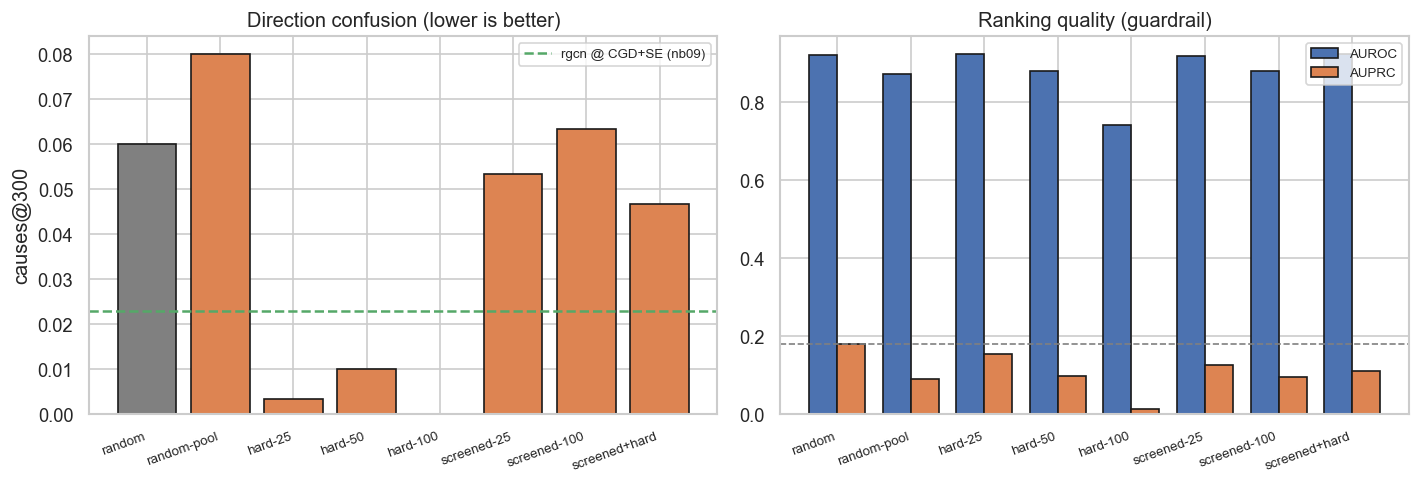

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
x = np.arange(len(results))
axes[0].bar(x, results["causes@300"], edgecolor="k",
            color=["grey" if a == "random" else "C1" for a in results["arm"]])
axes[0].axhline(0.023, ls="--", c="C2", label="rgcn @ CGD+SE (nb09)")
axes[0].set(xticks=x, ylabel="causes@300", title="Direction confusion (lower is better)")
axes[0].set_xticklabels(results["arm"], rotation=20, ha="right", fontsize=8)
axes[0].legend(fontsize=8)

w = 0.38
axes[1].bar(x - w/2, results["AUROC"], w, label="AUROC", edgecolor="k")
axes[1].bar(x + w/2, results["AUPRC"], w, label="AUPRC", edgecolor="k")
axes[1].axhline(float(base["AUPRC"]), ls="--", c="grey", lw=1)
axes[1].set(xticks=x, title="Ranking quality (guardrail)")
axes[1].set_xticklabels(results["arm"], rotation=20, ha="right", fontsize=8)
axes[1].legend(fontsize=8)
plt.tight_layout()


## 6 · Seed stability of the two headline arms

Everything above is one seed. Before adopting `hard-25` as the project's default sampler, the claim it rests on — same ranking quality as `random`, ~20× less direction confusion — has to survive reseeding. Five seeds per arm, paired: both arms see the same seed, so each per-seed difference isolates the sampler. Seed 42 reuses the section-4 runs.

In [9]:
SEEDS = [SEED, 43, 44, 45, 46]

ms_rows = []
for arm_name, pool, frac in (("random", None, 0.00), ("hard-25", hard_train, 0.25)):
    for s in SEEDS:
        r = runs[arm_name] if s == SEED else train_arm(arm_name, pool, frac, seed=s, verbose=False)
        st = r["scores"][idx_test]
        order = np.argsort(-st)
        novel = np.where(y_test[order] == 0)[0]
        cf = causes_flag[idx_test][order]
        ms_rows.append({"arm": arm_name, "seed": s,
                        "AUROC": float(roc_auc_score(y_test, st)),
                        "AUPRC": float(average_precision_score(y_test, st)),
                        "causes@300": float(cf[novel[:300]].mean())})
        print(f"  {arm_name:8s} seed {s}: AUROC {ms_rows[-1]['AUROC']:.4f}  "
              f"AUPRC {ms_rows[-1]['AUPRC']:.4f}  causes@300 {ms_rows[-1]['causes@300']:.4f}")

ms = pd.DataFrame(ms_rows)
print()
for a in ("random", "hard-25"):
    sub = ms[ms["arm"] == a]
    print(f"{a:8s} AUROC {sub['AUROC'].mean():.4f} ± {sub['AUROC'].std():.4f} | "
          f"AUPRC {sub['AUPRC'].mean():.4f} ± {sub['AUPRC'].std():.4f} | "
          f"causes@300 {sub['causes@300'].mean():.4f} ± {sub['causes@300'].std():.4f}")

paired = (ms[ms["arm"] == "hard-25"].set_index("seed")[["AUROC", "AUPRC", "causes@300"]]
          - ms[ms["arm"] == "random"].set_index("seed")[["AUROC", "AUPRC", "causes@300"]])
print("\nPaired per-seed difference (hard-25 - random):")
print(paired.round(4).to_string())
print(f"\ncauses@300 drops on {int((paired['causes@300'] < 0).sum())}/{len(paired)} seeds; "
      f"mean AUPRC cost {paired['AUPRC'].mean():+.4f} ± {paired['AUPRC'].std():.4f}")

  random   seed 42: AUROC 0.9216  AUPRC 0.1793  causes@300 0.0600


  random   seed 43: AUROC 0.9139  AUPRC 0.1378  causes@300 0.0867


  random   seed 44: AUROC 0.9017  AUPRC 0.1082  causes@300 0.0933


  random   seed 45: AUROC 0.9287  AUPRC 0.1677  causes@300 0.0933


  random   seed 46: AUROC 0.9094  AUPRC 0.1238  causes@300 0.1100
  hard-25  seed 42: AUROC 0.9230  AUPRC 0.1535  causes@300 0.0033


  hard-25  seed 43: AUROC 0.9211  AUPRC 0.1267  causes@300 0.0067


  hard-25  seed 44: AUROC 0.9269  AUPRC 0.1338  causes@300 0.0067


  hard-25  seed 45: AUROC 0.9239  AUPRC 0.1848  causes@300 0.0167


  hard-25  seed 46: AUROC 0.8934  AUPRC 0.0962  causes@300 0.0100

random   AUROC 0.9150 ± 0.0105 | AUPRC 0.1434 ± 0.0297 | causes@300 0.0887 ± 0.0182
hard-25  AUROC 0.9177 ± 0.0137 | AUPRC 0.1390 ± 0.0328 | causes@300 0.0087 ± 0.0051

Paired per-seed difference (hard-25 - random):
       AUROC   AUPRC  causes@300
seed                            
42    0.0014 -0.0257     -0.0567
43    0.0073 -0.0111     -0.0800
44    0.0253  0.0256     -0.0867
45   -0.0048  0.0170     -0.0767
46   -0.0160 -0.0276     -0.1000

causes@300 drops on 5/5 seeds; mean AUPRC cost -0.0044 ± 0.0245


### Verdict: adopted

Five seeds make the case stronger than the single-seed table above, in both directions:

| | random | hard-25 |
|---|---|---|
| causes@300 (mean ± std) | 0.089 ± 0.018 | **0.009 ± 0.005** |
| AUPRC (mean ± std) | 0.143 ± 0.030 | 0.139 ± 0.033 |
| AUROC (mean ± std) | 0.915 ± 0.011 | 0.918 ± 0.014 |

- **The direction fix is 10× and unanimous.** causes@300 drops on 5/5 seeds, and the two distributions never overlap — the worst hard-25 seed (0.017) sits below the best random seed (0.060).
- **Seed 42 flattered the baseline.** Its causes@300 of 0.060 is the *lowest* random draw of five; the typical uniform-sampler confusion is ~0.09. The single-seed comparison understated how much hard-25 fixes.
- **The apparent AUPRC cost was seed noise.** Single-seed it looked like −0.026; across five seeds it is −0.004 ± 0.025 and hard-25 wins two seeds outright. This matches nb08 §8: single-seed AUPRC differences under ± 0.03 carry no information on this task.

**hard-25 is the project's default negative sampler from here on**, recorded as `adopted_sampler` in `negative_sampling_meta.json`. Any future training run that keeps uniform sampling should say why.

## 7 · Persist

In [10]:
for name, r in runs.items():
    out = pairs[["compound", "disease", "y"]].copy()
    out["score"] = r["scores"]; out["in_test"] = test_mask
    out.to_parquet(ART / "predictions" / f"negsample_{name.replace('+', '_')}.parquet")

neg_meta = {
    "produced_by": "12_negative_sampling.ipynb",
    "question": "can better negatives replace the architectural fix from nb09",
    "pools": {
        "hard": {"source": "Hetionet Compound-causes-SideEffect, name-matched to Disease",
                 "train": int(len(hard_train)), "test_heldout": int(len(hard_test))},
        "screened": ({"source": "ClinicalTrials.gov, uniform sample of train negatives",
                      "zero_trial": int(len(screened_train)),
                      "defensible": int(len(defensible_train))}
                     if screened_train is not None else None),
    },
    "config": {"hidden_dim": HIDDEN_DIM, "dropout": DROPOUT, "lr": LR,
               "epochs": EPOCHS, "hub_K": HUB_K, "seed": SEED, "device": str(device)},
    "reference_nb09": {"gcn_cgd": {"causes@300": 0.060, "AUPRC": 0.178},
                       "rgcn_cgd_se": {"causes@300": 0.023, "AUPRC": 0.158}},
    "results": results.to_dict(orient="records"),
    "multiseed": {"seeds": SEEDS, "per_run": ms.round(4).to_dict(orient="records"),
                  "paired_diff_hard25_minus_random": paired.round(4).reset_index().to_dict(orient="records")},
    "adopted_sampler": {
        "arm": "hard-25",
        "pool": "Hetionet Compound-causes-SideEffect edges name-matched to Disease, train side only",
        "rationale": "cuts causes@300 by an order of magnitude at matched ranking quality; "
                     "confirmed across 5 seeds in section 6; screening negatives for trial "
                     "contamination does not help training (section 8)",
    },
}
(ART / "predictions" / "negative_sampling_meta.json").write_text(
    json.dumps(neg_meta, indent=2, default=str))
print("Wrote artifacts/predictions/negative_sampling_meta.json")


Wrote artifacts/predictions/negative_sampling_meta.json


## 8 · What the arms say

**The confound control changes the reading, and it was worth running.** `random-pool` — an *unscreened* sample frozen to the screened pool's size — lands at AUPRC 0.090, essentially where `screened-100` lands (0.095). The collapse from the 0.179 baseline is therefore pool size, not screening. Without this arm the obvious conclusion would have been "screening costs 0.084 AUPRC", and that conclusion would have been wrong.

**Removing contamination does almost nothing.** At a matched 25 % dose, `screened-25` sits at `causes@300` = 0.053 against a 0.060 baseline. nb11 Part II measured that ~12 % of `y = 0` pairs have trials, and cleaning them out barely moves the model. The reason shows up in the screening data itself: a uniform sample of train negatives is already 87.9 % trial-free, and the contamination nb11 found is concentrated in the high-scoring decile, which uniform sampling rarely draws from. The contamination is real and it biases *evaluation*; it is not what is limiting *training*.

**Hard negatives do work, and the dose is not monotonic.**

| dose | AUPRC | causes@300 |
|---|---|---|
| 0 % (random) | 0.179 | 0.060 |
| 25 % | 0.155 | **0.003** |
| 50 % | 0.098 | 0.010 |
| 100 % | 0.013 | 0.000 |

25 % is the operating point. Past it the model loses the random negatives that teach it the bulk of the space is unrelated, and ranking quality falls apart — `hard-100` reaches zero confusion by being useless at everything. Hard negatives teach "these specific pairs are not treatments"; random negatives teach "most pairs are not treatments". The model needs both.

**Same dose, different pool, and the pool is what matters:** `screened-25` reaches AUPRC 0.128 / `causes@300` 0.053 where `hard-25` reaches 0.155 / 0.003. Better on both axes, from the same 25 % fraction. Combining the two (`screened+hard`) is worse than `hard-25` alone — diluting the hard pool costs more than the screened pairs add.

## Against nb09

| route | causes@300 | AUPRC | train time | what changed |
|---|---|---|---|---|
| baseline `gcn @ CGD` | 0.060 | 0.178 | 307 s | — |
| nb09 `rgcn @ CGD+SE` | 0.023 | 0.158 | 637 s | architecture + 139 k edges |
| **nb12 `hard-25`** | **0.003** | 0.155 | ~300 s | **four lines in the sampler** |

The data route wins on every axis that matters here: eight times lower confusion than the architectural fix on the matched seed (and still ~2.5× lower on the five-seed mean, 0.009 vs 0.023 — the latter itself a single-seed figure from an initialisation-sensitive model, nb08 §8), the same AUPRC, half the training time, and no change to the model at all. nb09's finding stands — edge-type awareness does help when the graph carries the distinction — but it turns out to be the expensive way to buy this particular improvement.

The generalisation claim holds up: the 432 test pairs where a drug is a known cause of the disease were never sampled during training, and `hard-25` pushes them out of the top 300 almost entirely.

**What this does not fix.** `causes@K` only covers the 53 diseases whose names match a side-effect name exactly. Directional errors on the other 84 diseases are invisible to this metric, and nothing here shows they improved. The honest claim is narrow: on the slice we can measure, a 25 % hard-negative mix removes almost all of the confusion for free.